Del 1

In [42]:
import math
# populasjon i Trondheim
e = math.exp(1)

K = 1e6 # makspopulasjon i Trondheim er 1 million
P0 = 214565 # populasjon i Trondheim ved startår (2024)
r = 0.035 # relativ vekstrate på 3,5 %
start_aar = 2024
slutt_aar = 2044
t = slutt_aar-start_aar
A = (K-P0)/P0
sluttPopulasjon = K/(1+A*e**(-r*t))
sluttPopulasjon_avrundet = round(sluttPopulasjon, 2)
print("Populasjonen i Trondheim i år 2024 er", P0)
print("Sluttpopulasjonen i Trondheim i år 2044 er", sluttPopulasjon_avrundet)

vekst_i_perioden = sluttPopulasjon_avrundet-P0
vekst_i_prosent = vekst_i_perioden/P0*100
vekst_i_prosent_avrundet = round(vekst_i_prosent, 2)

print("I løpet av en 20-års periode, fra", start_aar, "til", slutt_aar,"forventes det dermed en økning i folketall på", vekst_i_perioden)
print("Dette er en vekst på", vekst_i_prosent_avrundet, "%")

Populasjonen i Trondheim i år 2024 er 214565
Sluttpopulasjonen i Trondheim i år 2044 er 354887.25
I løpet av en 20-års periode, fra 2024 til 2044 forventes det dermed en økning i folketall på 140322.25
Dette er en vekst på 65.4 %


Del 2

In [40]:
import json
with open("kundedata1.json", 'r') as file:
    kundedata = json.load(file)

# Lag sparefunksjon
def finn_sluttsaldo(sparebeløp,n,r,startsaldo,t):
    rn = r/n
    F = sparebeløp*((1+rn)**(n*t)-1)/rn
    start_forrenting = startsaldo*(r+1)**(t)
    return F + start_forrenting

# Hver kunde sparer 2000 kr hver måned (12 mnd), i 10 år, med en rente på 4%
sparebeløp = 2000
n = 12 
r = 0.04
t = 10

for kunde in kundedata:
    start_saldo = kunde["startsaldo"]
    slutt_saldo = finn_sluttsaldo(sparebeløp, n, r, start_saldo, t)
    kunde["sluttsaldo"] = slutt_saldo

import pprint
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(kundedata[:10])

# Lag histogram som viser fordelingen av sparepengene til kundene
import matplotlib.pyplot as plt
import numpy as np

sluttsaldo_liste = []
startsaldo_liste = []

for kunde in kundedata:
    sluttsaldo_liste.append(kunde["sluttsaldo"])
    startsaldo_liste.append(kunde["startsaldo"])

plt.hist(startsaldo_liste, bins=20, label="Startsaldo")
plt.hist(sluttsaldo_liste, bins=20, label="Startsaldo")
plt.legend()
plt.show()

# Finn gjennomsnitt, min og max av startsaldo og sluttsaldo

n_kunder = len(startsaldo_liste)

snitt_startsaldo = sum(startsaldo_liste)/n_kunder
snitt_startsaldo_avrundet = round(snitt_startsaldo, 2)
minste_startsaldo = min(startsaldo_liste)
max_startsaldo = max(startsaldo_liste)

snitt_sluttsaldo = sum(sluttsaldo_liste)/n_kunder
snitt_sluttsaldo_avrundet = round(snitt_sluttsaldo, 2)
minste_sluttsaldo = min(sluttsaldo_liste)
max_sluttsaldo = max(sluttsaldo_liste)

print("I snitt har kundene", snitt_startsaldo_avrundet, "på sparekonto ved start.", "Minste sum på sparekonto ved start er", minste_startsaldo, "og største sum ved start er", max_startsaldo)

print("Ved slutt, har kundene i snitt", snitt_sluttsaldo_avrundet, "på sparekonto.", "Minste sum ved slutt er", minste_sluttsaldo, "og største sum ved slutt er", max_sluttsaldo)

# Del inn kundene etter lite bemidlet, middels bemidlet og rike
# Definer terskelverdier for klassifisering, med utgangspunkt i startsaldo
lite_bemidlet_grense = 70000
høyt_bemidlet_grense = 140000

# Funksjon for å klassifisere kunder basert på startsaldo
def klassifiser_kunde(startsaldo):
    if startsaldo < lite_bemidlet_grense:
        return "Lite bemidlet"
    elif startsaldo > høyt_bemidlet_grense:
        return "Rik"
    else:
        return "Middels bemidlet"

# Oppdater kundedata med disse klassifiseringene, basert på sluttsaldo
for kunde in kundedata:
    kunde["klassifisering"] = klassifiser_kunde(kunde["startsaldo"])

pp.pprint(kundedata[:10])

# Vis hvor bemidlet kundene er med et kake-diagram
import matplotlib.pyplot as plt
import numpy as np

# Samle alle klassifiseringene i en liste, for alle kunder i kundedata
klassifisering_liste = [kunde["klassifisering"] for kunde in kundedata]

# Tell antall kunder i hver kategori
lite_bemidlet = klassifisering_liste.count("Lite bemidlet")
middels_bemidlet = klassifisering_liste.count("Middels bemidlet")
rik = klassifisering_liste.count("Rik")

# Definer data for kakediagrammet
labels = ["Lite bemidlet", "Middels bemidlet", "Rik"]
sizes = [lite_bemidlet, middels_bemidlet, rik]
colors = ['red', 'yellow', 'green']

plt.pie(sizes, labels=labels, colors=colors)
plt.title("Klassifisering av kunder")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'kundedata1.json'

Del 3

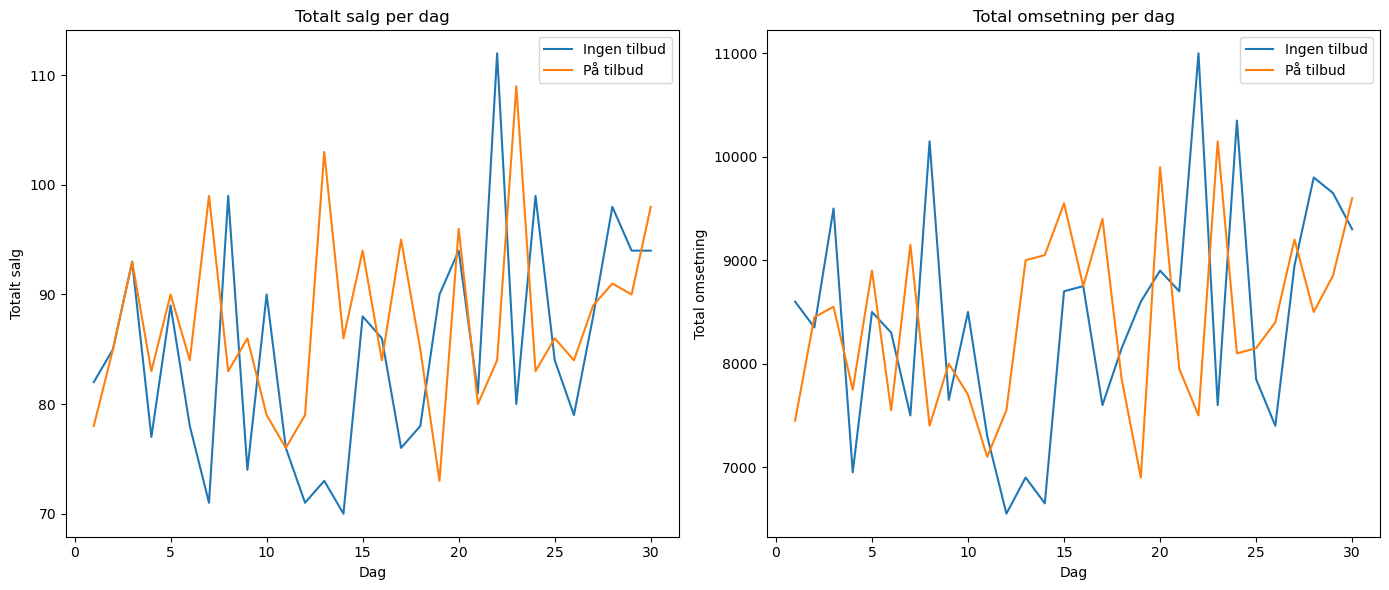


Forklaring av resultatene:
Denne koden simulerer salget og omsetningen i en butikk over en måned (30 dager) med og uten tilbud på produktene. 

Totalt salg uten tilbud: 2549
Total omsetning uten tilbud: 252700 NOK
Totalt salg med tilbud: 2625
Total omsetning med tilbud: 252350 NOK


In [29]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Definerer produktklassen
class Produkt:
    def __init__(self, navn, pris, grunn_prob):
        self.navn = navn
        self.pris = pris
        self.grunn_prob = grunn_prob

class Butikk:
    def __init__(self, produkter):
        self.produkter = produkter

    def simuler_dag(self, antall_kunder, rabatt_rate=0):
        total_salg = 0
        total_omsetning = 0

        for _ in range(antall_kunder):
            budsjett = random.gauss(600, 110) # Anta at gjennomsnittlig budsjett er 600 med std avvik på 110
            for produkt in self.produkter:
                prob = produkt.grunn_prob * (1 + rabatt_rate) / (1 + rabatt_rate * (1 - produkt.grunn_prob))
                if random.random() < prob and budsjett >= produkt.pris:
                    total_salg += 1
                    total_omsetning += produkt.pris
                    budsjett -= produkt.pris

        return total_salg, total_omsetning

# Produkter definert
produkter = [
    Produkt("Produkt A", 100, 0.1),
    Produkt("Produkt B", 200, 0.05),
    Produkt("Produkt C", 150, 0.08),
    Produkt("Produkt D", 50, 0.2)
]

# Oppretter butikk
butikk = Butikk(produkter)

# Antall kunder per dag
kunder_per_dag = 200
# Antall dager i måneden
dager_i_mnd = 30
# Rabatt
rabatt_rate = 0.2

# En mnd med og uten tilbud
salg_uten_tilbud = []
omsetning_uten_tilbud = []
salg_med_tilbud = []
omsetning_med_tilbud = []

for _ in range(dager_i_mnd):
    salg, omsetning = butikk.simuler_dag(kunder_per_dag, rabatt_rate=0)
    salg_uten_tilbud.append(salg)
    omsetning_uten_tilbud.append(omsetning)

    salg, omsetning = butikk.simuler_dag(kunder_per_dag, rabatt_rate=rabatt_rate)
    salg_med_tilbud.append(salg)
    omsetning_med_tilbud.append(omsetning)

# Plotter resultatene
dager = list(range(1, dager_i_mnd + 1))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(dager, salg_uten_tilbud, label='Ingen tilbud')
plt.plot(dager, salg_med_tilbud, label='På tilbud')
plt.xlabel('Dag')
plt.ylabel('Totalt salg')
plt.title('Totalt salg per dag')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dager, omsetning_uten_tilbud, label='Ingen tilbud')
plt.plot(dager, omsetning_med_tilbud, label='På tilbud')
plt.xlabel('Dag')
plt.ylabel('Total omsetning')
plt.title('Total omsetning per dag')
plt.legend()

plt.tight_layout()
plt.show()

# Forklaring av resultatene:
print("""
Forklaring av resultatene:
Denne koden simulerer salget og omsetningen i en butikk over en måned (30 dager) med og uten tilbud på produktene. 
""")

# Tekstformat av resultatene:
total_salg_uten_tilbud = sum(salg_uten_tilbud)
total_omsetning_uten_tilbud = sum(omsetning_uten_tilbud)
total_salg_med_tilbud = sum(salg_med_tilbud)
total_omsetning_med_tilbud = sum(omsetning_med_tilbud)

print(f"Totalt salg uten tilbud: {total_salg_uten_tilbud}")
print(f"Total omsetning uten tilbud: {total_omsetning_uten_tilbud} NOK")
print(f"Totalt salg med tilbud: {total_salg_med_tilbud}")
print(f"Total omsetning med tilbud: {total_omsetning_med_tilbud} NOK")